<a href="https://colab.research.google.com/github/pangavrii/Assessment-exercises---16069/blob/main/elearning-Assigment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Εργασία: Απειρόβαθο τετραγωνικό πηγάδι, με Python

**Μάθημα**: Προβλήματα Κβαντικής Φυσικής


Σε αυτή την εργασία θα μελετήσουμε το άπειρο τετραγωνικό φρέαρ (Infinite Square Well) μέσω της Python. Κάθε ερώτηση να συνοδεύεται από κώδικα και φυσική ερμηνεία των αποτελεσμάτων.

Ξεκινήστε συμπληρώνoντας τις ιδιοτιμές και τις ιδιοσυναρτήσεις (βλ. αντίστοιχο μάθημα και βιβλίο Zettili). Με βάση το πεδίο ορισμού (πλέγμα τιμών) που σας δίδεται. Θεωρείστε ότι $\hbar = m =1$

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

%matplotlib inline

L = 1.0
N = 1000
x = np.linspace(0, L, N)

def psi_n(n, x, L=1.0):
    return np.sqrt(2.0/L) * np.sin(n * np.pi * x / L)

def E_n(n, L=1.0):
    return (n**2 * np.pi**2) / (2.0 * L**2)

## Ερώτηση 1: Ιδιοκαταστάσεις και Ιδιοτιμές
Λαμβάνοντας υπόψη τα αποτελέσματα της λύσης της χρονικά ανεξάρτητης εξίσωσης Schrodinger για το Απειρόβαθο τετραγωνικό Πηγάδι (βλ. αντίστοιχη άσκηση).
Να γίνουν τα ακόλουθα:

**(α)** Υπολογισμός και σχεδίαση των πρώτων 3 ιδιοκαταστάσεων στο ίδιο γράφημα.

**(β)** Υπολογισμός των αντίστοιχων ιδιοτιμών ενέργειας.

**(γ)** Χρησιμοποιήστε την Python για να Υπολογίσετε την πιθανότητα να βρεθεί το σωματίδιο στο αριστερό μισό του πηγαδιού για την πρώτη ιδιοκατάσταση $ψ_1(x)$. Τι φυσικό συμπέρασμα προκύπτει;


<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1017/1132681262.py:4: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(x, psi_n(n, x, L), label=f'$\psi_{n}(x)$')
/tmp/ipykernel_1017/1132681262.py:6: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\psi_n(x)$')


TypeError: 'str' object is not callable

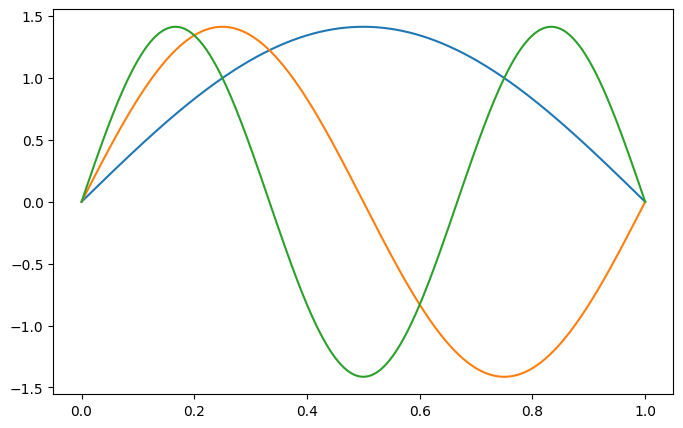

In [64]:
# (α)
plt.figure(figsize=(8, 5))
for n in [1, 2, 3]:
    plt.plot(x, psi_n(n, x, L), label=f'$\psi_{n}(x)$')
plt.xlabel('x')
plt.ylabel('$\psi_n(x)$')
plt.legend()
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

In [66]:
#(β)
for n in [1, 2, 3]:
    print(f"E_{n} = {E_n(n, L):.4f}")

E_1 = 4.9348
E_2 = 19.7392
E_3 = 44.4132


##  Ερώτηση 2: Χρονική Εξέλιξη Κυματοσυνάρτησης
**(α)** Θεωρώντας την αρχική κατάσταση: $\Psi(x,0) = \frac{1}{\sqrt{2}} (\psi_1 + \psi_2)$, οπου  $\psi_1$ , $\psi_2$ οι παραπάνω ιδιοσυναρτήσεις, να
υπολογίσετε και να σχεδιάστε την $|\Psi(x,t)|^2$ για διάφορες τιμές t (**times = [0, 1, 2, 3, 4]**) στο ίδιο διάγραμμα. Τι παρατηρείτε; Εξηγήστε το λόγο.



<>:17: SyntaxWarning: invalid escape sequence '\P'
<>:17: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_1017/918577984.py:17: SyntaxWarning: invalid escape sequence '\P'
  plt.ylabel('$|\Psi(x,t)|^2$')


TypeError: 'str' object is not callable

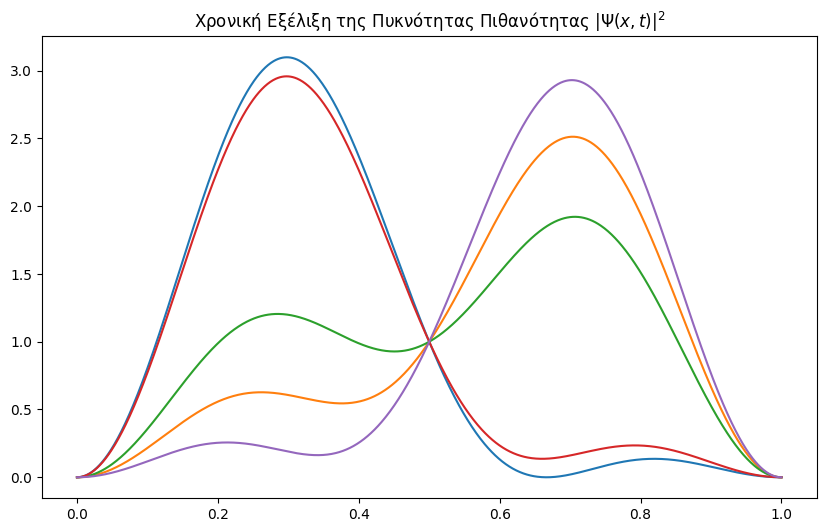

In [72]:
def Psi_superposition(x, t, L=1.0):
    # Εφόσον hbar = 1
    term1 = psi_n(1, x, L) * np.exp(-1j * E_n(1, L) * t)
    term2 = psi_n(2, x, L) * np.exp(-1j * E_n(2, L) * t)
    return (1.0/np.sqrt(2.0)) * (term1 + term2)

times = [0, 1, 2, 3, 4]
plt.figure(figsize=(10, 6))

for t in times:
    # Πυκνότητα πιθανότητας είναι το μέτρο στο τετράγωνο
    prob_density = np.abs(Psi_superposition(x, t, L))**2
    plt.plot(x, prob_density, label=f't = {t}')

plt.title('Χρονική Εξέλιξη της Πυκνότητας Πιθανότητας $|\Psi(x,t)|^2$')
plt.xlabel('x')
plt.ylabel('$|\Psi(x,t)|^2$')
plt.legend()
plt.grid(True)
plt.show()
#Υπάρχει ταλάντωση στην πυκνότητα πιθανότητας με την πάροδο του χρόνου.

## Ερώτηση 3: Αβεβαιότητα Θέσης
**(α)** Υπολογίστε την μέση τιμή $\langle x \rangle$ και την αβεβαιότητα $\sigma_x(t)$ για διάφορες τιμές του χρόνου από 0 έως 4π sec (6 τιμές) (**for t in np.linspace(0, 4*np.pi, 6)**) για την $\Psi(x,t)$

**(β)** Για  $\Psi=ψ_1(x)$ τι αποτελεσματα βγαίνουν για τους ιδιους χρόνους; πως εξηγούνται;

In [71]:
for t in np.linspace(0, 4*np.pi, 6):
    psi_t = Psi_superposition(x, t, L)
    prob_density = np.abs(psi_t)**2
    mean_x = np.trapz(x * prob_density, x)

    mean_x2 = np.trapz((x**2) * prob_density, x)

    sigma_x = np.sqrt(mean_x2 - mean_x**2)

    print(f"Χρόνος t = {t:5.2f} | <x> = {mean_x:.4f} | σ_x(t) = {sigma_x:.4f}")

prob_density_1 = np.abs(psi_n(1, x, L))**2

mean_x_1 = np.trapz(x * prob_density_1, x)
mean_x2_1 = np.trapz((x**2) * prob_density_1, x)

sigma_x_1 = np.sqrt(mean_x2_1 - mean_x_1**2)

for t in np.linspace(0, 4*np.pi, 6):
    print(f"Χρόνος t = {t:5.2f} | <x> = {mean_x_1:.4f} | σ_x(t) = {sigma_x_1:.4f}")

Χρόνος t =  0.00 | <x> = 0.3199 | σ_x(t) = 0.1387
Χρόνος t =  2.51 | <x> = 0.3412 | σ_x(t) = 0.1626
Χρόνος t =  5.03 | <x> = 0.4001 | σ_x(t) = 0.2042
Χρόνος t =  7.54 | <x> = 0.4827 | σ_x(t) = 0.2267
Χρόνος t = 10.05 | <x> = 0.5694 | σ_x(t) = 0.2165
Χρόνος t = 12.57 | <x> = 0.6396 | σ_x(t) = 0.1794
Χρόνος t =  0.00 | <x> = 0.5000 | σ_x(t) = 0.1808
Χρόνος t =  2.51 | <x> = 0.5000 | σ_x(t) = 0.1808
Χρόνος t =  5.03 | <x> = 0.5000 | σ_x(t) = 0.1808
Χρόνος t =  7.54 | <x> = 0.5000 | σ_x(t) = 0.1808
Χρόνος t = 10.05 | <x> = 0.5000 | σ_x(t) = 0.1808
Χρόνος t = 12.57 | <x> = 0.5000 | σ_x(t) = 0.1808


/tmp/ipykernel_1017/812537783.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mean_x = np.trapz(x * prob_density, x)
/tmp/ipykernel_1017/812537783.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mean_x2 = np.trapz((x**2) * prob_density, x)
/tmp/ipykernel_1017/812537783.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mean_x_1 = np.trapz(x * prob_density_1, x)
/tmp/ipykernel_1017/812537783.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mean_x2_1 = np.trapz((x**2) * prob_density_1, x)


Την συγκεκριμένη εργασία ΔΕΝ την έκανα μόνος μου καθώς χρησιμοποίησα στο μεγαλύτερο κομμάτι βοήθεια από τεχνητή νοημοσύνης. Νομίζω φαίνεται και από το γεγονός πως είναι σε πολλά κομμάτια ελλειπής.